# 11주차 3차시: 멀티모달 검색 시스템 (CLIP, Qdrant, 한국어 검색)

| 주제 | 내용 |
|---|---|
| CLIP 멀티모달 임베딩 | 이미지·텍스트를 같은 벡터 공간에 인코딩, zero-shot 분류 원리 |
| 인코딩 함수화 | encode_image_clip, encode_text_clip (정규화 임베딩) |
| 이미지 인덱싱·검색 | 텍스트→이미지, 이미지→이미지 유사도 검색 |
| Qdrant 벡터 DB | named vector(image·caption), 필터·hybrid search |
| 한국어 멀티모달 검색 | Korean CLIP(Bingsu), 한국어 캡션 인덱싱·쿼리 |

In [ ]:
# 환경 설정 및 라이브러리 설치
!pip install -q transformers torch qdrant-client pillow numpy python-dotenv

In [2]:
import os, io
from pathlib import Path
from typing import List, Optional
from dotenv import load_dotenv

load_dotenv()

import numpy as np
import torch
from PIL import Image
from transformers import CLIPProcessor, CLIPModel

In [3]:
# !pip install transformers

In [4]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

/home/oncreative/anaconda3/envs/modu/lib/python3.11/site-packages/torch/cuda/__init__.py:187: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [5]:
IMAGE_DIR = Path('data/images')

## CLIP 모델과 멀티모달 임베딩 원리

- 멀티모달 표현의 두 경로: (1) 이미지 → Vision LLM → 텍스트 캡션 → 임베딩, (2) 이미지 → 이미지 인코더 → 임베딩
- CLIP은 이미지·텍스트를 같은 벡터 공간에 인코딩해 modality 간 유사도 비교가 가능함
- `openai/clip-vit-base-patch32`로 zero-shot 분류 시연: 후보 텍스트들과 이미지의 유사도(softmax)를 비교
- vision/text 인코더의 pooler 출력을 `visual_projection`으로 512차원 공유 공간에 투영

In [6]:
# 이미지, 테이블, 그래프 -> vision LLM -> text captioning -> embedding 

In [7]:
# 이미지 -> 이미지 인코더 -> embedding

In [8]:
MODEL_NAME = "openai/clip-vit-base-patch32"

In [9]:
model = CLIPModel.from_pretrained(MODEL_NAME, use_safetensors = True).to(DEVICE).eval()

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [10]:
processor = CLIPProcessor.from_pretrained(MODEL_NAME)

In [11]:
# model.config

In [12]:
img = Image.open(IMAGE_DIR / 'shapes_red_blue.png').convert('RGB') # ARGB

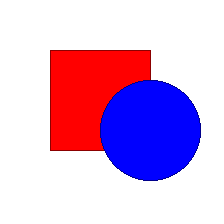

In [13]:
img

In [14]:
candidates = [
    'a red square and a blue ellipse on white background',
    'a quarterly revenue bar chart',
    'a dashboard with KPI cards',
    'a photo of dog'
]

In [15]:
inputs = processor(text=candidates, images=img, return_tensors = 'pt', padding=True).to(DEVICE)

In [16]:
with torch.no_grad():
    out = model(**inputs)


In [17]:
probs = out.logits_per_image.softmax(dim=1)[0].cpu().numpy()

In [18]:
out.logits_per_image.softmax(dim=1)[0].cpu().numpy()

array([9.9993098e-01, 3.2100284e-05, 4.3054294e-07, 3.6526992e-05],
      dtype=float32)

In [19]:
for c, p in zip(candidates, probs):
    print(f" {p}, {c}")

 0.9999309778213501, a red square and a blue ellipse on white background
 3.210028444300406e-05, a quarterly revenue bar chart
 4.3054293996647175e-07, a dashboard with KPI cards
 3.652699160738848e-05, a photo of dog


In [20]:
inputs['pixel_values'].shape

torch.Size([1, 3, 224, 224])

In [21]:
with torch.no_grad():
    vision_out = model.vision_model(pixel_values = inputs['pixel_values'])

In [22]:
vision_out.pooler_output.shape

torch.Size([1, 768])

In [23]:
model.visual_projection(vision_out.pooler_output).shape

torch.Size([1, 512])

In [24]:
model.visual_projection(vision_out.pooler_output)[0].shape

torch.Size([512])

## 이미지·텍스트 인코딩 함수

- `encode_image_clip(image)`, `encode_text_clip(text)`로 임베딩 추출을 함수화함
- 코사인 유사도는 `dot(a, b) / (norm(a)*norm(b))`이며, 임베딩을 L2 정규화하면 내적만으로 유사도 계산이 가능함

In [25]:
def encode_image_clip(image) -> np.ndarray:
    inputs = processor(images=image.convert('RGB'), return_tensors = 'pt').to(DEVICE)
    with torch.no_grad():
        vision_out = model.vision_model(pixel_values = inputs['pixel_values'])
        pooled = vision_out.pooler_output   # [1, 768]
        projected = model.visual_projection(pooled) # [1, 512]
    
    feat = projected[0].cpu().numpy()  # [512]
    return feat / np.linalg.norm(feat)  # feat / || feat ||



In [ ]:
# image_emb = image_feat / np.linalg.norm(image_feat)

# text_emb = text_feat / np.linalg.norm(text_feat)

In [ ]:
# np.dot(image_feat, text_feat)
# image_feat @ text_feat

In [ ]:
# a, b -> np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

In [26]:
e = encode_image_clip(Image.open(IMAGE_DIR / 'shapes_red_blue.png'))

In [27]:
e.shape

(512,)

In [28]:
np.linalg.norm(e)

np.float32(0.99999994)

In [29]:
inputs = processor(text=['a red square and a blue ellipse on white background'], return_tensors = 'pt', padding=True).to(DEVICE)
inputs

{'input_ids': tensor([[49406,   320,   736,  3999,   537,   320,  1746,  3367,  5423,   525,
          1579,  5994, 49407]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}

In [30]:
inputs['input_ids'].shape

torch.Size([1, 13])

In [31]:
model.text_model(input_ids = inputs['input_ids'], attention_mask = inputs.get('attention_mask')).pooler_output.shape

torch.Size([1, 512])

In [32]:
def encode_text_clip(text : str) -> np.ndarray:
    inputs = processor(text=[text], return_tensors = 'pt', padding=True).to(DEVICE)
    with torch.no_grad():
        text_out = model.text_model(input_ids = inputs['input_ids'], attention_mask = inputs.get('attention_mask'))
        pooled = text_out.pooler_output # (1, 512)
        projected = model.text_projection(pooled)  # (1, 512)
    
    feat = projected[0].cpu().numpy()  # [512]
    return feat / np.linalg.norm(feat)  # feat / || feat ||

In [33]:
t = encode_text_clip('a red square and a blue ellipse on white background')
t.shape

(512,)

## 이미지 인덱싱 & 검색

- 폴더 내 이미지들을 인코딩해 임베딩 행렬로 인덱싱함 (`build_image_index`)
- `search_by_text`: 텍스트 쿼리를 인코딩해 이미지와의 유사도 상위 k개 반환
- `search_by_image`: 쿼리 이미지로 유사 이미지 검색 (이미지 to 이미지)

In [35]:
image_paths = sorted(IMAGE_DIR.glob('*.png'))
image_paths

[PosixPath('data/images/_eq_gauss.png'),
 PosixPath('data/images/chart_monthly_sales.png'),
 PosixPath('data/images/chart_quarterly.png'),
 PosixPath('data/images/dashboard_v1.png'),
 PosixPath('data/images/dashboard_v2.png'),
 PosixPath('data/images/document_invoice.png'),
 PosixPath('data/images/document_report.png'),
 PosixPath('data/images/gradient_shapes.png'),
 PosixPath('data/images/ir_report_page.png'),
 PosixPath('data/images/org_chart.png'),
 PosixPath('data/images/shapes_red_blue.png'),
 PosixPath('data/images/test_counting.png'),
 PosixPath('data/images/test_small_text.png'),
 PosixPath('data/images/test_spatial.png')]

In [36]:
embeddings = np.stack([encode_image_clip(Image.open(p)) for p in image_paths])
embeddings.shape

(14, 512)

In [37]:
queries = [
    'a bar chart of revenue',
    'an invoice document', 
    'a dashboard with KPIs',
    'korean text'
]

In [38]:
for q in queries:
    q_emb = encode_text_clip(q)
    sims = embeddings @ q_emb
    top3 = np.argsort(-sims)[:3]
    print(q)
    for i in top3:
        print(f" {sims[i]} ---- {image_paths[i].name}")

a bar chart of revenue
 0.2951543629169464 ---- chart_quarterly.png
 0.2849935293197632 ---- chart_monthly_sales.png
 0.2651922404766083 ---- ir_report_page.png
an invoice document
 0.299247145652771 ---- document_invoice.png
 0.2611232101917267 ---- test_small_text.png
 0.23696690797805786 ---- document_report.png
a dashboard with KPIs
 0.3255186080932617 ---- dashboard_v2.png
 0.32344377040863037 ---- dashboard_v1.png
 0.2791062593460083 ---- chart_monthly_sales.png
korean text
 0.23687079548835754 ---- _eq_gauss.png
 0.23490531742572784 ---- shapes_red_blue.png
 0.21888156235218048 ---- test_spatial.png


In [39]:
def build_image_index(paths) -> tuple: #(embs , paths):
    embs = np.stack([encode_image_clip(Image.open(p)) for p in paths])
    return embs, list(paths)

In [40]:
def search_by_text(text, embeddings, paths, k=3) -> list:
    q = encode_text_clip(text)
    sims = embeddings @ q
    top = np.argsort(-sims)[:k]
    return [(paths[i], float(sims[i])) for i in top]

In [42]:
embs, paths = build_image_index(image_paths)
for q in ['bar chart', 'math equation']:
    for p, s in search_by_text(q, embs, paths, k=2):
        print(q)
        print(f"{s}  {p.name}")

bar chart
0.2896374762058258  chart_quarterly.png
bar chart
0.2765522003173828  chart_monthly_sales.png
math equation
0.29785099625587463  _eq_gauss.png
math equation
0.2495494782924652  test_spatial.png


In [43]:
def search_by_image(query_image, embeddings, paths, k=3):
    q = encode_image_clip(query_image)
    sims = embeddings @ q
    top = np.argsort(-sims)[:k]
    return [(paths[i], float(sims[i])) for i in top]

## Qdrant 벡터 DB: 필터·hybrid search

- 벡터 검색 옵션(FAISS·Chroma·Qdrant) 중 Qdrant를 사용해 named vector(`image`, `caption`)를 한 컬렉션에 저장 (둘 다 512차원·COSINE)
- `filename_to_caption`으로 파일명을 캡션으로 변환해 payload에 저장
- `search_qdrant`: 특정 벡터(image 또는 caption) 기준 검색
- `search_with_filter`: 캡션에 키워드가 포함된 결과만 후필터링
- `hybrid_search`: image·caption 점수를 `alpha`로 가중 합산해 재정렬 (alpha=1 이미지, 0 캡션)

In [ ]:
# FAISS
# chromadb

# qdrant

In [ ]:
# !pip install qdrant-client

In [44]:
from qdrant_client import QdrantClient

In [45]:
from qdrant_client.models import VectorParams, Distance, PointStruct, NamedVector, Filter, FieldCondition, MatchValue

In [47]:
client = QdrantClient(":memory:")
COLLECTION = "multimodal_demo"

In [48]:
client.create_collection(collection_name = COLLECTION, 
                        vectors_config = {
                            "image" : VectorParams(
                                            size = 512,
                                            distance = Distance.COSINE
                                    ),
                            "caption" : VectorParams(
                                            size = 512,
                                            distance = Distance.COSINE
                                    ),
#                             'audio' : Vector
                        })

True

In [49]:
def filename_to_caption(path):
    return path.stem.replace("_", "")  # chart_quarterly.png -> chart quarterly

In [52]:
points = []
for i, p in enumerate(paths):
    img = Image.open(p)
    img_emb = encode_image_clip(img)
    caption = filename_to_caption(p)
    cap_emb = encode_text_clip(caption)
    points.append(PointStruct(
        id = i,
        vector = {'image' : img_emb.tolist(), 'caption' : cap_emb.tolist()},
        payload = {'path' : str(p), 'filename' : p.name, 'caption' : caption}
    ))

In [54]:
# points

In [55]:
client.upsert(collection_name=COLLECTION, points= points)

UpdateResult(operation_id=0, status=<UpdateStatus.COMPLETED: 'completed'>)

In [56]:
def search_qdrant(client, query_emb, vector_name, k):
    result = client.query_points(collection_name = COLLECTION, query = query_emb.tolist(), using=vector_name, limit=k)
    
    return [
        {'path' : h.payload['filename'], 'caption' : h.payload['caption'], 'score' : h.score}
        for h in result.points
    ]

In [57]:
q_text = 'bar chart'
q_emb = encode_text_clip(q_text)
for r in search_qdrant(client, q_emb, 'image', k=3):
    print(f" {r['score']} {r['path']}")

 0.28963749576563724 chart_quarterly.png
 0.27655220033022054 chart_monthly_sales.png
 0.25878316102390697 dashboard_v1.png


In [58]:
for r in search_qdrant(client, q_emb, 'caption', k=3):
    print(f" {r['score']} {r['path']}")

 0.8331049769727217 org_chart.png
 0.820218872311763 chart_monthly_sales.png
 0.8201419899200202 ir_report_page.png


In [60]:
def search_with_filter(client, query_emb, vector_name, filter_keyword: str, k=3):
    result = client.query_points(collection_name = COLLECTION, query = query_emb.tolist(), using=vector_name, limit=k*3)
    filtered = [h for h in result.points if filter_keyword.lower() in h.payload['caption'].lower()]
    
    return [
        {'path' : h.payload['filename'], 'caption' : h.payload['caption'], 'score' : h.score}
        for h in filtered[:k]
    ]
#     파일명에 filter_keyword 가 포함된 애들만 검색

In [ ]:
# vector cos sim -> keyword -> 

In [65]:
def hybrid_search(client, query_emb, alpha = 0.5, k = 3):
    img_hits = client.query_points(collection_name = COLLECTION, query = query_emb.tolist(), using='image', limit=k*3).points
    cap_hits = client.query_points(collection_name = COLLECTION, query = query_emb.tolist(), using='caption', limit=k*3).points
    
    score = {}
    for h in img_hits:
        score[h.id] = score.get(h.id, {'img' : 0, 'cap' : 0, 'payload' : h.payload})
        score[h.id]['img'] = h.score
    for h in cap_hits:
        score[h.id] = score.get(h.id, {'img' : 0, 'cap' : 0, 'payload' : h.payload})
        score[h.id]['cap'] = h.score
    
    ranked = sorted(
        score.items(), key = lambda x : alpha * x[1]['img'] + (1-alpha) * x[1]['cap'], reverse=True
    )
    
    return [{
        "path" : v['payload']['filename'],
        'img_score' : v['img'], 'cap_score' : v['cap'],
        'hybrid' : alpha * v['img'] + (1-alpha) * v['cap']
    }
    for _, v in ranked[:k]]
        

In [66]:
q_emb = encode_text_clip('monthly revenue chart')
for r in hybrid_search(client, q_emb, alpha=0.5, k=3):
    print(f" hybrid = {r['hybrid']} (img = {r['img_score']}, cap = {r['cap_score']})")

 hybrid = 0.5786621901673794 (img = 0.3190593003360622, cap = 0.8382650799986966)
 hybrid = 0.5380164486039009 (img = 0.28583915473429133, cap = 0.7901937424735104)
 hybrid = 0.5288980293956813 (img = 0.2277985550536316, cap = 0.829997503737731)


## 한국어 멀티모달 검색 (Korean CLIP)

- 영어 CLIP을 한국어로 확장하는 세 방법: (1) 한국어 데이터 fine-tuning, (2) distillation, (3) 처음부터 다국어 모델 학습
- `Bingsu/clip-vit-base-patch32-ko`(distillation 기반)로 한국어 텍스트·이미지를 인코딩함
- `korean_captions`로 이미지별 한국어 캡션을 부여하고, `index_with_ko_captions`로 image·caption 벡터를 Qdrant에 인덱싱
- `search_ko`: 한국어 쿼리로 멀티모달 검색

In [ ]:
# clip -> 한글
# 1. openai clip-vit ->한국어 데이터로 학습 : 한국어 데이터로 fine-tuning
# 2. distillation -> clip-vit 
#                      |
#                    clip-vit-ko 모델을 학습
# 3. 처음부터 새로운 다국어 모델 -> 영어, 중국어, 한국어

In [67]:
MODEL_NAME = "Bingsu/clip-vit-base-patch32-ko"

In [68]:
model = CLIPModel.from_pretrained(MODEL_NAME, use_safetensors=True).to(DEVICE).eval()

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [69]:
proecssor = CLIPProcessor.from_pretrained(MODEL_NAME)

In [71]:
model.config.projection_dim

512

In [74]:
model

CLIPModel(
  (text_model): CLIPTextModel(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1

In [75]:
def encode_text_ko(text) -> np.ndarray:
    inputs = processor(text = [text], return_tensors = 'pt', padding=True).to(DEVICE)
    with torch.no_grad():
        text_out = model.text_model(
                    input_ids = inputs['input_ids'], attention_mask = inputs['attention_mask'])
        pooled = text_out.pooler_output
        projected = model.text_projection(pooled)
    
    feat = projected[0].cpu().numpy()
    return feat / np.linalg.norm(feat)

In [76]:
ko = encode_text_ko('노을 진 바다')
en = encode_text_ko('a sunset over the sea')

np.dot(ko, en)

np.float32(0.95634615)

In [82]:
def encode_image_ko(image) -> np.ndarray:
    inputs = processor(images = image.convert('RGB'), return_tensors = 'pt').to(DEVICE)
    with torch.no_grad():
        vision_out = model.vision_model(
                    pixel_values = inputs['pixel_values'])
        pooled = vision_out.pooler_output
        projected = model.visual_projection(pooled)
    
    feat = projected[0].cpu().numpy()
    return feat / np.linalg.norm(feat) 

In [83]:
def korean_captions(paths):
    table = {
        "chart_quarterly.png":     "분기별 매출 막대 차트",
        "chart_monthly_sales.png": "월별 매출 차트",
        "dashboard_v1.png":        "KPI 대시보드",
        "dashboard_v2.png":        "지표 대시보드 v2",
        "document_invoice.png":    "인보이스 문서",
        "document_report.png":     "보고서 문서",
        "ir_report_page.png":      "IR 보고서 페이지",
        "org_chart.png":           "조직도",
        "shapes_red_blue.png":     "흰 배경 위의 빨간 사각형과 파란 타원",
        "test_counting.png":       "개수 세기 테스트 이미지",
        "test_small_text.png":     "작은 글씨 테스트 이미지",
        "test_spatial.png":        "공간 배치 테스트 이미지",
        "test_color.png":          "색상 테스트 이미지",
    }
    return {p.name: table.get(p.name, p.stem.replace("_", " ")) for p in paths}

In [84]:
caps = korean_captions(image_paths)

In [85]:
def index_with_ko_captions(client, collection : str, paths : list, captions : dict):
    dim = model.config.projection_dim
    if client.collection_exists(collection):
        client.delete_collection(collection)
    client.create_collection(
        collection_name = collection,
        vectors_config = {
            'image' : VectorParams(size= dim, distance = Distance.COSINE),
            'caption' :VectorParams(size= dim, distance = Distance.COSINE),
        }
    )
    
    points = []
    for i, p in enumerate(paths):
        img_emb = encode_image_ko(Image.open(p))
        ko_cap = captions[p.name]
        cap_emb = encode_text_ko(ko_cap)
        points.append(PointStruct(
            id = i,
            vector = {'image' : img_emb.tolist(), 'caption' : cap_emb.tolist()},
            payload = {'filename' : p.name, 'caption_ko' : ko_cap}
        ))
    
    client.upsert(collection_name = collection, points = points)
    return len(points)
    

In [86]:
client = QdrantClient(":memory:")
COLLECTION = "ko_demo"
n = index_with_ko_captions(client, COLLECTION, image_paths, caps)

### 한국어 쿼리로 검색

In [88]:
def search_ko(client, query: str, vector_name: str = "caption", k: int = 3) -> list:
    q_emb = encode_text_ko(query)
    result = client.query_points(
        collection_name=COLLECTION,
        query=q_emb.tolist(),
        using=vector_name,
        limit=k,
    )
    return [
        {"filename": h.payload["filename"],
         "caption_ko": h.payload["caption_ko"],
         "score": h.score}
        for h in result.points
    ]

for q in ["분기별 매출", "대시보드", "문서"]:
    print(f"\n'{q}' — caption 벡터로 검색")
    for r in search_ko(client, q, "caption", k=3):
        print(f"  {r['score']:+.4f}  {r['filename']:30s} ({r['caption_ko']})")


'분기별 매출' — caption 벡터로 검색
  +0.9931  chart_quarterly.png            (분기별 매출 막대 차트)
  +0.9754  ir_report_page.png             (IR 보고서 페이지)
  +0.9752  document_report.png            (보고서 문서)

'대시보드' — caption 벡터로 검색
  +0.9951  dashboard_v1.png               (KPI 대시보드)
  +0.9879  dashboard_v2.png               (지표 대시보드 v2)
  +0.9651  document_report.png            (보고서 문서)

'문서' — caption 벡터로 검색
  +0.9914  document_report.png            (보고서 문서)
  +0.9751  chart_quarterly.png            (분기별 매출 막대 차트)
  +0.9722  ir_report_page.png             (IR 보고서 페이지)
